In [1]:
# 0. Imports (all allowed in course)
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [13]:
analysis = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv')
scoring = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

In [14]:
# Start from your raw dfs: analysis, scoring
df_list = [analysis, scoring]

for df in df_list:
    # 1. Proxy for total monthly charge volume
    df["txn_amount_proxy"] = df["num_transactions"] * df["avg_transaction_value"]
    
    # 2. Share of transactions that are online
    df["online_share"] = df["online_shopping_freq"] / (df["num_transactions"] + 1)
    
    # 3. Share of transactions that are utility bills
    df["utilities_share"] = df["utility_payment_count"] / (df["num_transactions"] + 1)

In [15]:
target = "monthly_spend"
id_col = "customer_id"

y = analysis[target]
X = analysis.drop(columns=[target])
X_test_full = scoring.copy()

Numeric: ['customer_id', 'age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards', 'txn_amount_proxy', 'online_share', 'utilities_share']
Categorical: ['gender', 'marital_status', 'education_level', 'region', 'employment_status', 'card_type']


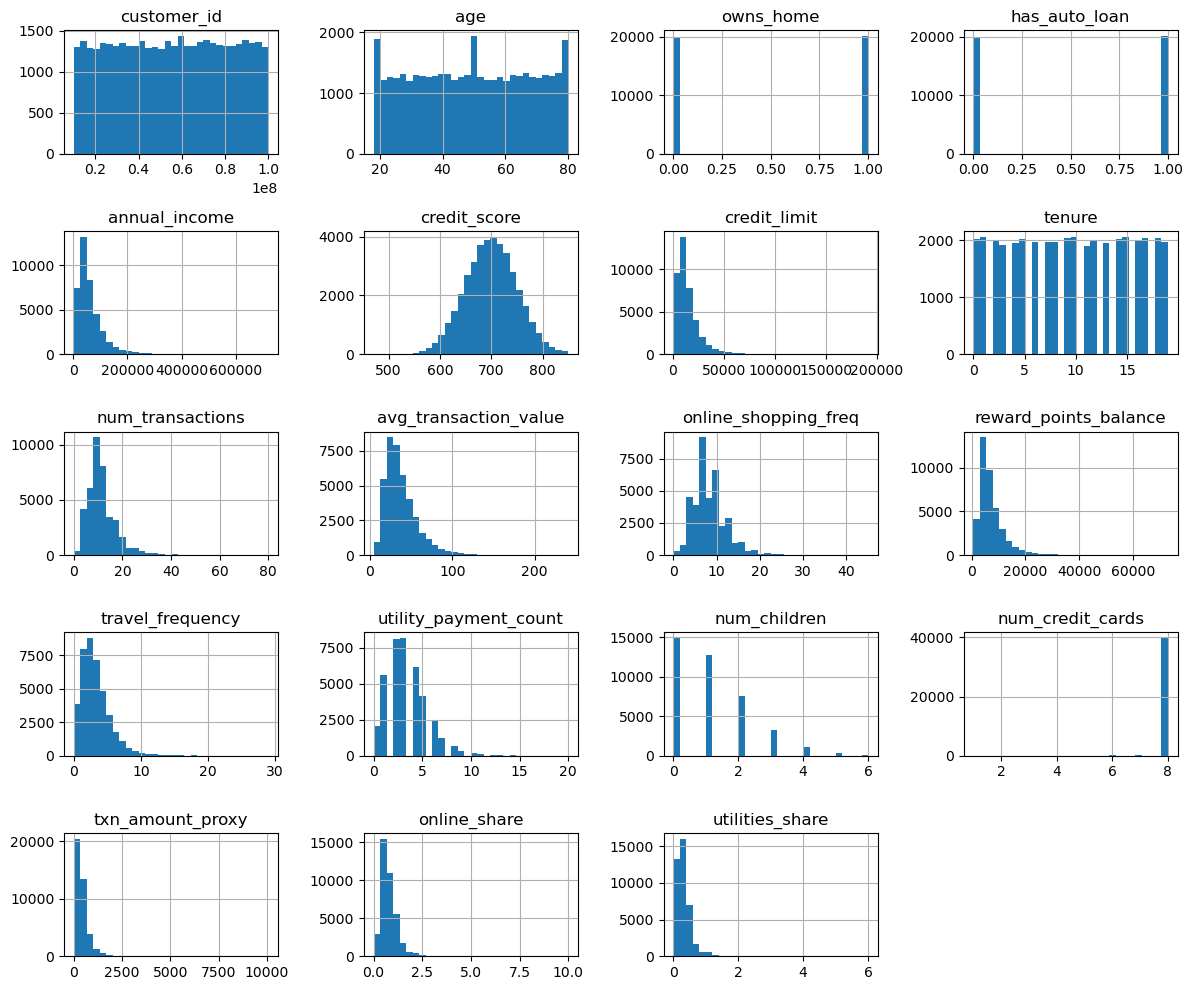

In [16]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", cat_cols)

# Quick look at skew
X[numeric_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()


In [6]:
X_test = X_test_full.drop(columns=[id_col])
# Log-transform strongly skewed numeric features
log_features = [
    "annual_income",
    "credit_limit",
    "num_transactions",
    "avg_transaction_value",
    "online_shopping_freq",
    "reward_points_balance",
    "travel_frequency",
    "utility_payment_count"
]

for col in log_features:
    if col in X.columns:
        X[col] = np.log1p(X[col])
        X_test[col] = np.log1p(X_test[col])

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=1031
)

In [8]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [9]:
from sklearn.metrics import make_scorer

rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False  # so GridSearchCV minimizes it
)

In [10]:
models_and_grids = []

# 1) ElasticNet (regularized linear)
en_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=5000, random_state=1031))
])

en_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
models_and_grids.append(("ElasticNet", en_model, en_grid))

# 2) Random Forest
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        random_state=1031,
        n_jobs=-1
    ))
])

rf_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [6, 10, None],
    "model__min_samples_leaf": [10, 20],
}
models_and_grids.append(("RandomForest", rf_model, rf_grid))

# 3) Gradient Boosting
gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=1031))
])

gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [10, 20]
}
models_and_grids.append(("GradientBoosting", gb_model, gb_grid))

In [11]:
best_models = {}
results = []

cv = KFold(n_splits=5, shuffle=True, random_state=1031)

for name, pipeline, param_grid in models_and_grids:
    print(f"=== {name} ===")
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=rmse_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    # negative RMSE → multiply by -1
    best_rmse = -grid.best_score_
    print(f"Best CV RMSE: {best_rmse:.2f}")
    print("Best params:", grid.best_params_)
    
    # Evaluate on held-out validation set (final overfitting check)
    y_valid_pred = grid.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    print(f"Validation RMSE: {valid_rmse:.2f}")
    
    results.append((name, best_rmse, valid_rmse))
    best_models[name] = grid.best_estimator_


=== ElasticNet ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV RMSE: 273.51
Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Validation RMSE: 280.65
=== RandomForest ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV RMSE: 277.93
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Validation RMSE: 280.28
=== GradientBoosting ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV RMSE: 256.27
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Validation RMSE: 256.21


In [12]:
results_df = pd.DataFrame(results, columns=["Model", "CV_RMSE", "Valid_RMSE"])
print(results_df.sort_values("Valid_RMSE"))

              Model     CV_RMSE  Valid_RMSE
2  GradientBoosting  256.267379  256.212611
1      RandomForest  277.929335  280.279630
0        ElasticNet  273.508857  280.649865


In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

gb2_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=1031))
])

gb2_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [5, 10],
    "model__subsample": [0.7, 1.0],
    "model__max_features": ["sqrt", None]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1031)

gb2_search = GridSearchCV(
    estimator=gb2_model,
    param_grid=gb2_grid,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb2_search.fit(X_train, y_train)

best_gb2 = gb2_search.best_estimator_
print("Best GB2 CV RMSE:", -gb2_search.best_score_)
print("Best GB2 params:", gb2_search.best_params_)

# Check against held-out validation set (overfitting check)
y_valid_pred_gb2 = best_gb2.predict(X_valid)
gb2_valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_gb2))
print("GB2 Validation RMSE:", gb2_valid_rmse)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best GB2 CV RMSE: 255.05717751649536
Best GB2 params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 300, 'model__subsample': 0.7}
GB2 Validation RMSE: 255.34178399305392


In [19]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

en_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=5000, random_state=1031))
])

en_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1031)

en_search = GridSearchCV(
    estimator=en_model,
    param_grid=en_grid,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

en_search.fit(X_train, y_train)

best_en = en_search.best_estimator_
print("Best EN CV RMSE:", -en_search.best_score_)
print("Best EN params:", en_search.best_params_)


# Fit both on the same training data
best_en.fit(X_train, y_train)
best_gb2.fit(X_train, y_train)

# Validation predictions
y_valid_en = best_en.predict(X_valid)
y_valid_gb2 = best_gb2.predict(X_valid)

# Simple 50/50 blend
y_valid_blend = 0.5 * y_valid_en + 0.5 * y_valid_gb2
blend_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_blend))
print("Blend Validation RMSE:", blend_rmse)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best EN CV RMSE: 273.50885687632166
Best EN params: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Blend Validation RMSE: 260.98444800561913


In [22]:
pre = best_gb2.named_steps["preprocess"]

used_num_cols = pre.transformers_[0][2]   # numeric columns used in pipeline
used_cat_cols = pre.transformers_[1][2]   # categorical columns used in pipeline

used_cols = list(used_num_cols) + list(used_cat_cols)

missing = [c for c in used_cols if c not in X.columns]
print("Columns expected by the model but missing from X:", missing)

Columns expected by the model but missing from X: ['customer_id']


In [23]:
id_col = "customer_id"
target = "monthly_spend"

# y: target
y = analysis[target]

# X: keep customer_id this time (only drop target)
X = analysis.drop(columns=[target])   # <-- DO NOT DROP customer_id here

# Test side: keep all feature columns
X_test_full = scoring.copy()
X_test = X_test_full.drop(columns=[])  # or simply: X_test = X_test_full.copy()

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# This is the GridSearchCV object you just ran:
# gb2_search = GridSearchCV(...)

best_gb2 = gb2_search.best_estimator_

# Train on full analysis data (same feature set as during CV)
best_gb2.fit(X, y)

# Predict on scoring data
test_preds = best_gb2.predict(X_test)

# Build submission
submission = pd.DataFrame({
    "customer_id": X_test_full[id_col],
    "monthly_spend": test_preds
})

submission.to_csv("submission_gb2_final.csv", index=False)
print(submission.head())


   customer_id  monthly_spend
0     20451981    1859.297847
1     23251656    2720.698370
2     64082260    1443.541927
3     82505923    2051.399100
4     89981994    1409.722591
